## Modeling: Layer 3

Now we have come to the final section for this project. We have trained models to predict which customers are likely to buy the term deposit loan, and we trained models that have helped the company understand who they should continue to call. We have one last question that still needs to be answered, namely: can we group the customers into clusters? This would help the bank understand which kind of customer they should target, ones that would very likely successfully purchase the loan.

In [43]:
X=X_3.copy()
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1


In [44]:
binary_mappings={
    'default':{'yes':1,'no':0},
    'housing':{'yes':1,'no':0},
    'loan':{'yes':1,'no':0}
}

In [46]:
# select only the subscribers
X.loc[:,'y']=y       # temporarily add y so that we can drop these rows
X=X[X['y']==1]       # filter out for only subscribers
X=X.drop('y',axis=1) # drop y

if X['default'].isna().sum()!=0: # in case I run this cell more than once
    for column,mapping in binary_mappings.items():
        X[column]=X[column].map(mapping)

X_encoded=pd.get_dummies(X,drop_first=True)
    
X_encoded.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
83,59,2343,5,1042,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
86,56,45,5,1467,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
87,41,1270,5,1389,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
129,55,2476,5,579,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
168,54,184,5,673,2,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [47]:
# scaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_encoded)
X_scaled=pd.DataFrame(data=X_scaled,columns=X_encoded.columns)
X_scaled.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,1.741354,0.258004,-1.265409,0.832632,-0.613443,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,...,-0.332309,-0.018586,-0.310732,-0.115308,-0.390981,-0.33614,-0.212391,1.631315,-0.286727,-0.131191
1,1.468629,-0.527801,-1.265409,1.818224,-0.613443,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,...,-0.332309,-0.018586,-0.310732,-0.115308,-0.390981,-0.33614,-0.212391,1.631315,-0.286727,-0.131191
2,0.105003,-0.108910,-1.265409,1.637339,-0.613443,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,...,-0.332309,-0.018586,-0.310732,-0.115308,-0.390981,-0.33614,-0.212391,1.631315,-0.286727,-0.131191
3,1.377720,0.303484,-1.265409,-0.241084,-0.613443,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,...,-0.332309,-0.018586,-0.310732,-0.115308,-0.390981,-0.33614,-0.212391,1.631315,-0.286727,-0.131191
4,1.286812,-0.480270,-1.265409,-0.023094,-0.179720,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,...,-0.332309,-0.018586,-0.310732,-0.115308,-0.390981,-0.33614,-0.212391,1.631315,-0.286727,-0.131191


In [48]:
X_scaled.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct'],
      dtype='object')

We will now transpose the columns so that we treat the features as observations to compare one to each other. A dendrogram will be instructive here to see the patterns that emerge.

### Dendrogram

In [49]:
# transpose to compare features as observations
X_scaled_t=X_scaled.T
X_scaled_t.head()

,0,1,2,3,4,5,6,7,8,9,...,2886,2887,2888,2889,2890,2891,2892,2893,2894,2895
age,1.741354,1.468629,0.105003,1.377720,1.286812,0.195911,1.468629,1.832262,-0.076814,-0.258631,...,-0.076814,-0.804081,1.832262,-1.349531,0.468637,-0.985898,1.377720,-1.258623,-0.894989,1.286812
balance,0.258004,-0.527801,-0.108910,0.303484,-0.480270,-0.543189,-0.259369,-0.356825,14.929443,-0.542847,...,-0.491896,-0.241587,-0.418035,-0.136608,-0.473431,-0.325366,0.271682,-0.122246,0.598930,-0.474799
day,-1.265409,-1.265409,-1.265409,-1.265409,-1.265409,-1.265409,-1.148534,-1.148534,-1.148534,-1.148534,...,-1.499160,-1.499160,-1.499160,-1.499160,-1.499160,-1.499160,-1.499160,-1.499160,-1.499160,-1.499160
duration,0.832632,1.818224,1.637339,-0.241084,-0.023094,-0.280508,1.201359,0.804803,2.179995,-0.173832,...,-0.897373,-0.630683,-0.208618,-1.201167,-1.064344,-0.795335,-0.213256,-0.690978,-1.031877,-1.189572
campaign,-0.613443,-0.613443,-0.613443,-0.613443,-0.179720,-0.179720,-0.613443,-0.613443,-0.613443,-0.613443,...,0.687727,-0.613443,-0.613443,-0.613443,-0.179720,-0.613443,-0.179720,-0.179720,0.254004,-0.613443


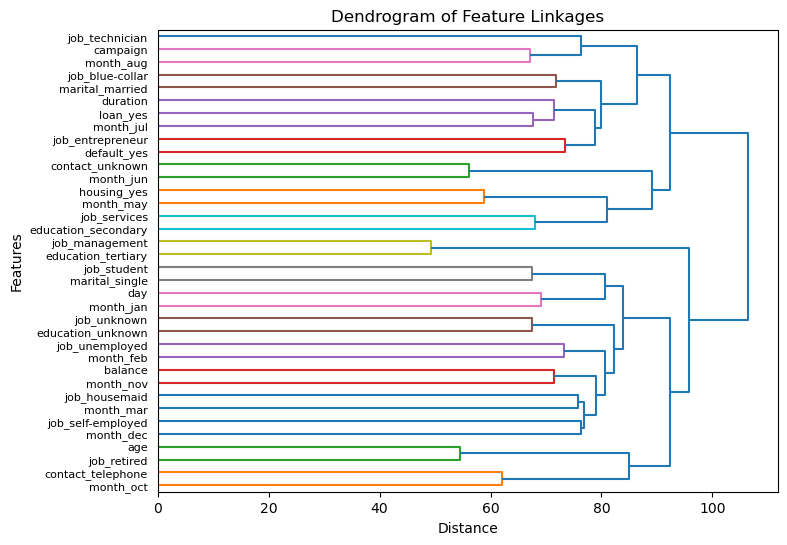

In [50]:
plt.figure(figsize=(8,6))
links=linkage(X_scaled_t,method='ward',metric='euclidean')
dendrogram(links,
           labels=X_scaled_t.index,orientation='right',distance_sort='descending',show_leaf_counts=True)
plt.ylabel('Features')
plt.xlabel('Distance')
plt.title('Dendrogram of Feature Linkages')

plt.savefig('../figs/2_l3_dendrogram.png')
plt.savefig('../figs/2_l3_dendrogram.pdf')
plt.savefig('../figs/2_l3_dendrogram.jpg')

plt.show()

### Clustering

In [88]:
X=X_3.copy()
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1


In [89]:
binary_mappings={
    'default':{'yes':1,'no':0},
    'housing':{'yes':1,'no':0},
    'loan':{'yes':1,'no':0}
}

In [90]:
# select only the subscribers
X.loc[:,'y']=y       # temporarily add y so that we can drop these rows
X=X[X['y']==1]       # filter out for only subscribers
X=X.drop('y',axis=1) # drop y

if X['default'].isna().sum()!=0: # in case I run this cell more than once
    for column,mapping in binary_mappings.items():
        X[column]=X[column].map(mapping)

X_encoded=pd.get_dummies(X,drop_first=True)
    
X_encoded.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
83,59,2343,5,1042,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
86,56,45,5,1467,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
87,41,1270,5,1389,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
129,55,2476,5,579,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
168,54,184,5,673,2,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [96]:
X_norm=pd.DataFrame(normalize(X_encoded),columns=X_encoded.columns)
X_norm_t=X_norm.T
print(X_norm_t.shape)
X_norm_t.head()

(36, 2896)


,0,1,2,3,4,5,6,7,8,9,...,2886,2887,2888,2889,2890,2891,2892,2893,2894,2895
age,0.023002,0.038127,0.021779,0.021625,0.077164,0.074521,0.038330,0.051420,0.000861,0.060739,...,0.116709,0.031842,0.085783,0.020822,0.146904,0.040130,0.022396,0.020154,0.008959,0.201487
balance,0.913471,0.030638,0.674623,0.973501,0.262929,0.000000,0.568109,0.467065,0.999357,0.001642,...,0.448883,0.905953,0.523275,0.990288,0.665963,0.881476,0.970351,0.954212,0.997430,0.746248
day,0.001949,0.003404,0.002656,0.001966,0.007145,0.008872,0.004107,0.005142,0.000133,0.009850,...,0.008978,0.003081,0.004289,0.002499,0.009794,0.004151,0.001222,0.002325,0.000896,0.011194
duration,0.406247,0.998796,0.737835,0.227648,0.961690,0.997163,0.822047,0.882709,0.035846,0.998094,...,0.885795,0.422162,0.847820,0.137424,0.731253,0.470490,0.240654,0.298433,0.071074,0.634311
campaign,0.000390,0.000681,0.000531,0.000393,0.002858,0.003549,0.000684,0.000857,0.000022,0.001642,...,0.011970,0.001027,0.001430,0.000833,0.006529,0.001384,0.000814,0.001550,0.000896,0.003731


#### Dendrogram

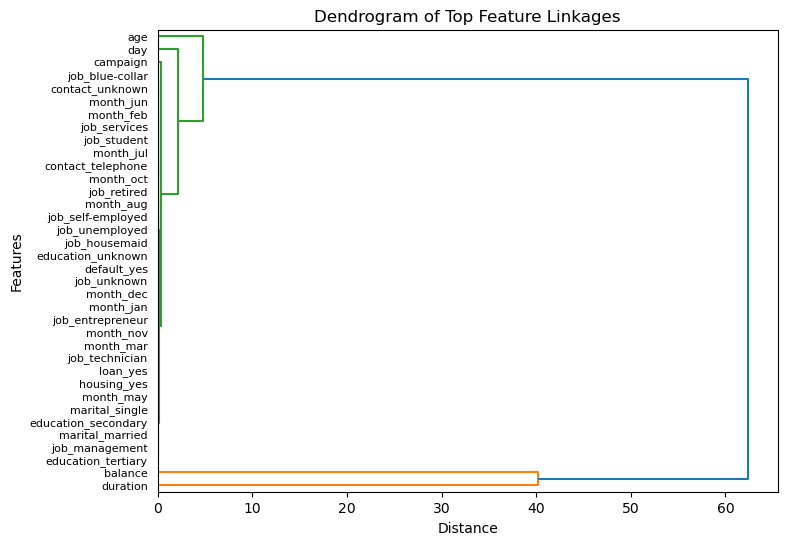

In [100]:
plt.figure(figsize=(8,6))
links=linkage(X_norm_t,method='ward',metric='euclidean')
dendrogram(
    links,
    labels=X_encoded.columns,
    orientation='right',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.ylabel('Features')
plt.xlabel('Distance')
plt.title('Dendrogram of Top Feature Linkages')

plt.savefig('../figs/2_l3_dendrogram.png')
plt.savefig('../figs/2_l3_dendrogram.pdf')
plt.savefig('../figs/2_l3_dendrogram.jpg')

plt.show()

#### Elbow Plot

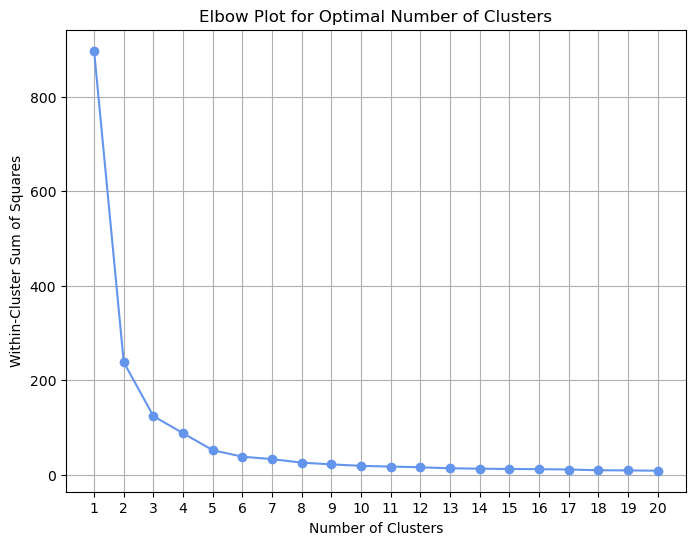

In [107]:
wcss=[] # within-cluster sum of squares
range_=range(1,21)

for i in range_:
    kmeans=KMeans(n_clusters=i,random_state=seed)
    kmeans.fit(X_norm)
    wcss.append(kmeans.inertia_)
    
# plot elbow plot
plt.figure(figsize=(8,6))
plt.plot(range_,wcss,marker='o',color='cornflowerblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.title('Elbow Plot for Optimal Number of Clusters')
plt.grid('minor')
plt.xticks(range_)

plt.savefig('../figs/2_l3_elbow.png')
plt.savefig('../figs/2_l3_elbow.pdf')
plt.savefig('../figs/2_l3_elbow.jpg')

plt.show()

It seems like three or five clusters capture the most amount of information.

#### Generate Labels

In [132]:
n_clusters=3
kmeans=KMeans(n_clusters=n_clusters,random_state=seed)
kmeans.fit(X_norm)
X_norm['cluster_label_3']=kmeans.labels_
X['cluster_label_3']=kmeans.labels_

ValueError: Length of values (2896) does not match length of index (40000)

In [116]:
n_clusters=5
kmeans=KMeans(n_clusters=n_clusters,random_state=seed)
kmeans.fit(X_norm)
X_norm['cluster_label_5']=kmeans.labels_

In [117]:
X_norm['cluster_label_3'].value_counts()

cluster_label_3
1    1192
0     917
2     787
Name: count, dtype: int64

In [118]:
X_norm['cluster_label_5'].value_counts()

cluster_label_5
1    1192
0     800
3     416
2     371
4     117
Name: count, dtype: int64

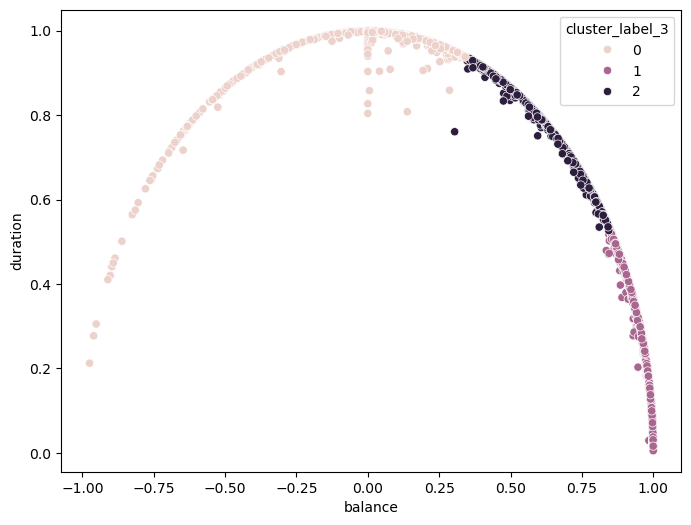

In [124]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=X_norm,x='balance',y='duration',hue='cluster_label_3')

plt.savefig('../figs/2_l3_scatter3.png')
plt.savefig('../figs/2_l3_scatter3.pdf')
plt.savefig('../figs/2_l3_scatter3.jpg')

plt.show()

In [131]:
for i in range(0, len(X['cluster_label_3'].unique())):    
    job = X[X['cluster_label_3']==i]['job'].value_counts().index[0]
    job_count = round((X[X['cluster_label_3']==i]['job'].value_counts()[0]/X[X['cluster_label_3']==i]['job'].value_counts().sum()), 3)*100
    education = X[X['cluster_label_3']==i]['education'].value_counts().index[0]
    marital = X[X['cluster_label_3']==i]['marital'].value_counts().index[0]
    age = X[X['cluster_label_3']==i]['age'].median()
    balance = X[X['cluster_label_3']==i]['balance'].median()
    print(f"Group {i} has a median age of {age} and a median balance of €{balance}.\n\tThey predominantly have {education} education, have jobs as {job} that make up {job_count}% of their group, and are {marital}.")

KeyError: 'cluster_label_3'

In [126]:
X=X_3

dummied_X=pd.get_dummies(X)
numeric_cols=[col for col in dummied_X.columns if dummied_X[col].dtype!='category']
dummied_X=dummied_X[numeric_cols].astype(float)
dummied_X.head()

,age,balance,day,duration,campaign,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,58.0,2143.0,5.0,261.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,44.0,29.0,5.0,151.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,33.0,2.0,5.0,76.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,47.0,1506.0,5.0,92.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,33.0,1.0,5.0,198.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Unsupervised Learning

#### Prepare dataset for unsupervised learning

In [199]:
# define and dummify
X=df[df['y']=='yes'].copy() # filter X 
X=pd.get_dummies(X,drop_first=True)

# normalize dataset
X_norm=pd.DataFrame(normalize(X),columns=X.columns)
X_norm.shape

(2896, 36)

In [200]:
X_norm.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,0.023002,0.913471,0.001949,0.406247,0.000390,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000390,0.0,0.0
1,0.038127,0.030638,0.003404,0.998796,0.000681,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000681,0.0,0.0
2,0.021779,0.674623,0.002656,0.737835,0.000531,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000531,0.0,0.0
3,0.021625,0.973501,0.001966,0.227648,0.000393,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000393,0.0,0.0
4,0.077164,0.262929,0.007145,0.961690,0.002858,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001429,0.0,0.0


#### Dendrogram

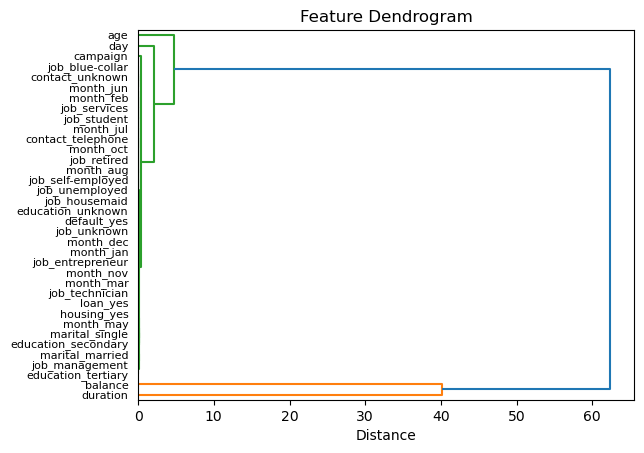

In [201]:
links=linkage(X_norm.T,method='ward',metric='euclidean')
dendrogram(links,labels=X.columns,orientation='right',distance_sort='descending')
plt.xlabel('Distance')
plt.title('Feature Dendrogram')
plt.show()

#### Elbow Plot: KMeans Clustering

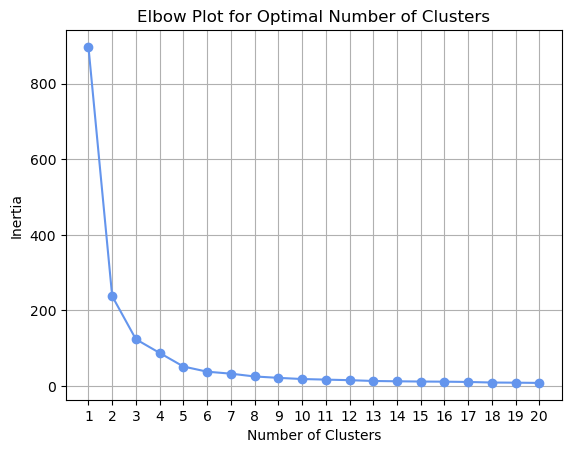

In [202]:
wcss=[] # within-cluster sum of means i.e., inertia
range_=range(1,21)

for i in range_:
    kmeans = KMeans(n_clusters=i, random_state=seed).fit(X_norm)
    wcss.append(kmeans.inertia_)

plt.plot(range_, wcss, marker='o',color='cornflowerblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Optimal Number of Clusters')
plt.grid('minor')
plt.xticks(range_)
         
plt.savefig('../figs/2_l3_elbow.png')
plt.savefig('../figs/2_l3_elbow.pdf')
plt.savefig('../figs/2_l3_elbow.jpg')
         
plt.show()

#### 3 Clusters

In [203]:
# Apply KMeans with chosen clusters
n_clusters=3
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
X['kmeans_label'] = kmeans.fit_predict(X_norm)
X.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,kmeans_label
83,59,2343,5,1042,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1
86,56,45,5,1467,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0
87,41,1270,5,1389,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,2
129,55,2476,5,579,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1
168,54,184,5,673,2,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0


##### Cluster Analysis

In [204]:
X['kmeans_label'].value_counts()

kmeans_label
1    1192
0     917
2     787
Name: count, dtype: int64

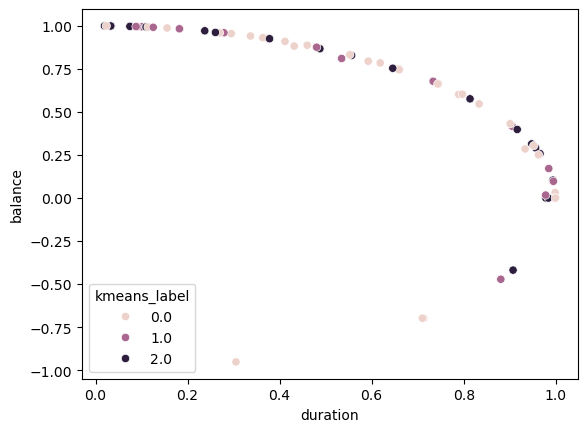

In [206]:
sns.scatterplot(data=X_norm, x='duration', y='balance', hue=X['kmeans_label'])
plt.show()

In [207]:
X.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'kmeans_label'],
      dtype='object')

##### Dimensionality Reduction

PCA

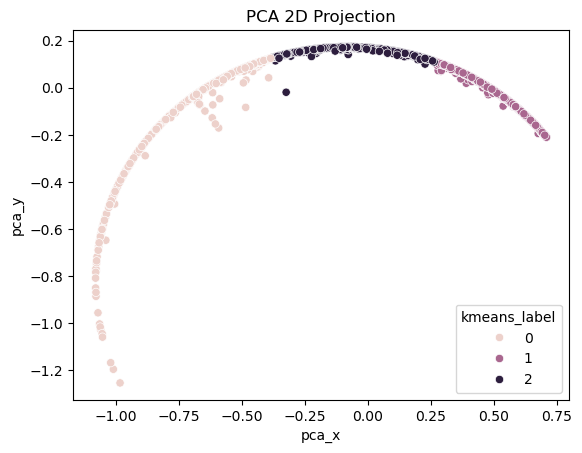

In [209]:
pca = PCA(n_components=3, random_state=seed)
X['pca_x'],X['pca_y'],X['pca_z'] = zip(*pca.fit_transform(X_norm))
sns.scatterplot(data=X, x='pca_x', y='pca_y', hue='kmeans_label')
plt.title("PCA 2D Projection")
plt.show()

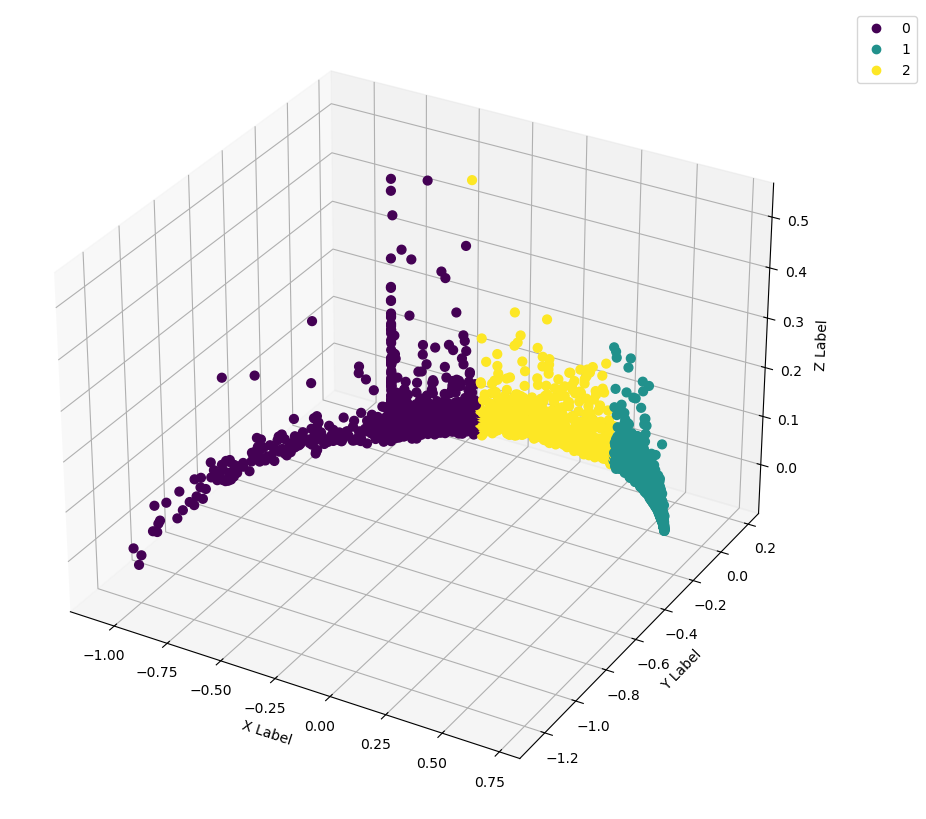

In [221]:
fig=plt.figure(figsize=(8,8))
ax=Axes3D(fig,auto_add_to_figure=False)
fig.add_axes(ax)

# plot
sc = ax.scatter(xs=X['pca_x'],ys=X['pca_y'],zs=X['pca_z'],s=40,c=X['kmeans_label'],marker='o',alpha=1)
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# legend
plt.legend(*sc.legend_elements(), bbox_to_anchor=(1.05, 1), loc=2)

plt.show()

# sns.scatterplot(data=X, x='pca_x', y='pca_y', z='pca_z', hue='kmeans_label')
# plt.title("PCA 3D Projection")
# plt.show()

t-SNE

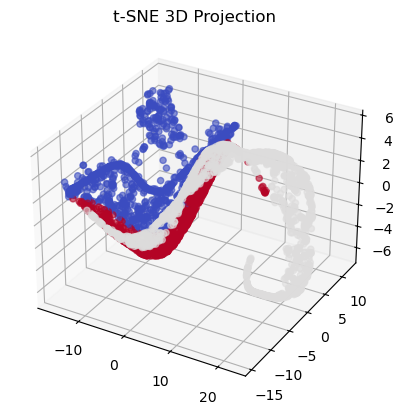

In [165]:
tsne = TSNE(n_components=3, random_state=seed, perplexity=50)
X[['tsne_x', 'tsne_y', 'tsne_z']] = tsne.fit_transform(X[numeric_cols])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['tsne_x'], X['tsne_y'], X['tsne_z'], c=X['kmeans_label'], cmap='coolwarm', alpha=0.6)
plt.title("t-SNE 3D Projection")
plt.show()

UMAP

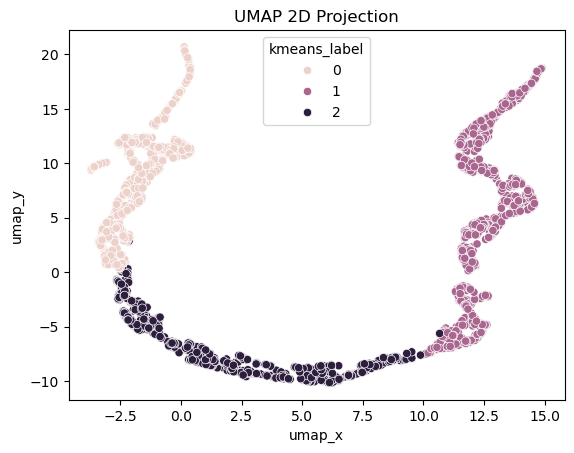

In [226]:
umap = UMAP()
X[['umap_x', 'umap_y']] = umap.fit_transform(X_norm)
sns.scatterplot(data=X, x='umap_x', y='umap_y', hue='kmeans_label')
plt.title("UMAP 2D Projection")
plt.show()

In [236]:
X['job']=X_3['job']
X['education']=X_3['education']
X['marital']=X_3['marital']

In [245]:
# Summarize clusters by selected attributes
for label in sorted(X['kmeans_label'].unique()):
    cluster = X[X['kmeans_label'] == label]
    job = cluster['job'].value_counts().idxmax()
    job_pct = round(cluster['job'].value_counts().max() / len(cluster) * 100, 1)
    education = cluster['education'].value_counts().idxmax()
    marital = cluster['marital'].value_counts().idxmax()
    age_median = cluster['age'].median()
    balance_median = cluster['balance'].median()
    print(f"Cluster {label} || median age: {age_median}")
    print(f"          || Median balance: €{balance_median}")
    print(f"          || Predominantly {education} educated")
    print(f"          || Jobs as {job} ({job_pct}%)")
    print(f"          || Mostly {marital}")
    print("\n")

Cluster 0 || median age: 36.0
          || Median balance: €22.0
          || Predominantly secondary educated
          || Jobs as blue-collar (21.5%)
          || Mostly married


Cluster 1 || median age: 39.0
          || Median balance: €2326.0
          || Predominantly tertiary educated
          || Jobs as management (28.3%)
          || Mostly married


Cluster 2 || median age: 37.0
          || Median balance: €556.0
          || Predominantly secondary educated
          || Jobs as blue-collar (21.6%)
          || Mostly married




#### 5 Clusters

In [246]:
# Apply KMeans with chosen clusters
n_clusters=5
kmeans=KMeans(n_clusters=n_clusters, random_state=seed)
X['kmeans_label']=kmeans.fit_predict(X_norm)
X.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_oct,kmeans_label,pca_x,pca_y,pca_z,umap_x,umap_y,job,education,marital
83,59,2343,5,1042,1,False,False,False,False,False,...,False,3,0.393644,0.054409,-0.014220,12.043678,-3.973933,admin,secondary,married
86,56,45,5,1467,1,False,False,False,False,False,...,False,0,-0.667059,-0.017899,-0.033873,-1.867051,10.044309,admin,secondary,married
87,41,1270,5,1389,1,False,False,False,False,False,...,False,2,0.002099,0.169925,-0.032922,2.594651,-9.466632,technician,secondary,married
129,55,2476,5,579,1,False,False,False,False,False,...,False,1,0.550357,-0.049899,-0.006293,12.562833,4.413229,services,secondary,married
168,54,184,5,673,2,False,False,False,False,False,...,False,0,-0.462059,0.096417,0.007214,-2.860924,3.112118,admin,tertiary,married


##### Cluster Analysis

In [247]:
X['kmeans_label'].value_counts()

kmeans_label
1    943
0    742
2    560
3    535
4    116
Name: count, dtype: int64

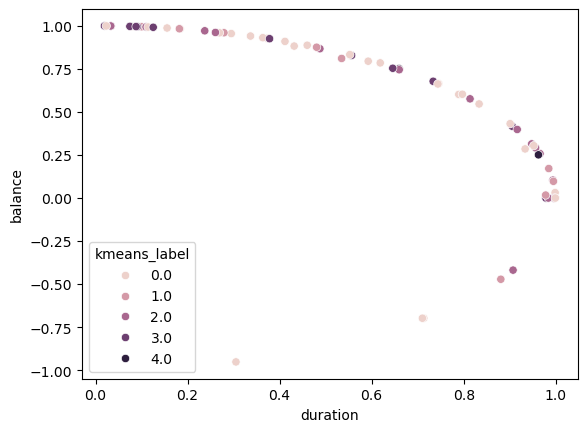

In [248]:
sns.scatterplot(data=X_norm, x='duration', y='balance', hue=X['kmeans_label'])
plt.show()

In [249]:
X.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'kmeans_label', 'pca_x', 'pca_y', 'pca_z', 'umap_x',
       'umap_y', 'job', 'education', 'marital'],
      dtype='object')

##### Dimensionality Reduction

PCA

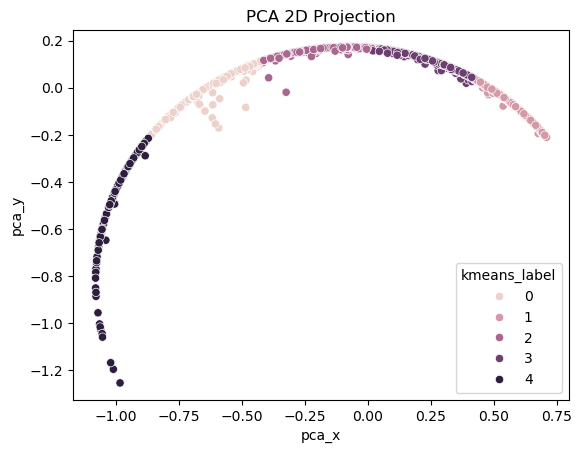

In [250]:
pca = PCA(n_components=3, random_state=seed)
X['pca_x'],X['pca_y'],X['pca_z'] = zip(*pca.fit_transform(X_norm))
sns.scatterplot(data=X, x='pca_x', y='pca_y', hue='kmeans_label')
plt.title("PCA 2D Projection")
plt.show()

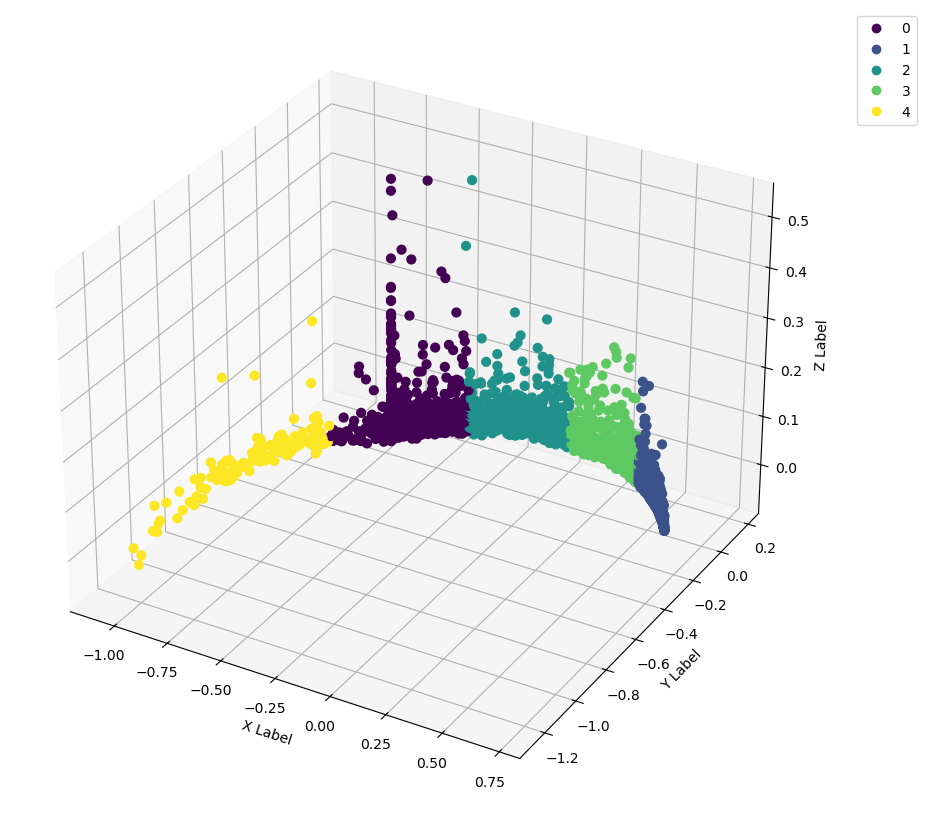

In [251]:
fig=plt.figure(figsize=(8,8))
ax=Axes3D(fig,auto_add_to_figure=False)
fig.add_axes(ax)

# plot
sc = ax.scatter(xs=X['pca_x'],ys=X['pca_y'],zs=X['pca_z'],s=40,c=X['kmeans_label'],marker='o',alpha=1)
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# legend
plt.legend(*sc.legend_elements(), bbox_to_anchor=(1.05, 1), loc=2)

plt.show()

# sns.scatterplot(data=X, x='pca_x', y='pca_y', z='pca_z', hue='kmeans_label')
# plt.title("PCA 3D Projection")
# plt.show()

t-SNE

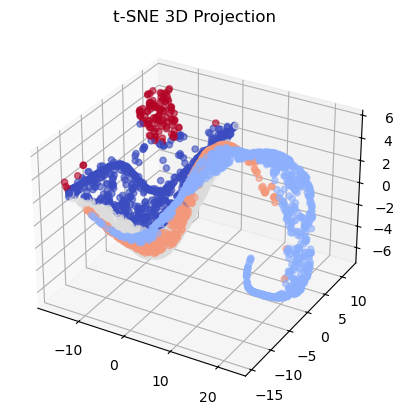

In [253]:
tsne = TSNE(n_components=3, random_state=seed, perplexity=50)
X[['tsne_x', 'tsne_y', 'tsne_z']] = tsne.fit_transform(X[numeric_cols])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['tsne_x'], X['tsne_y'], X['tsne_z'], c=X['kmeans_label'], cmap='coolwarm', alpha=0.6)
plt.title("t-SNE 3D Projection")
plt.show()

UMAP

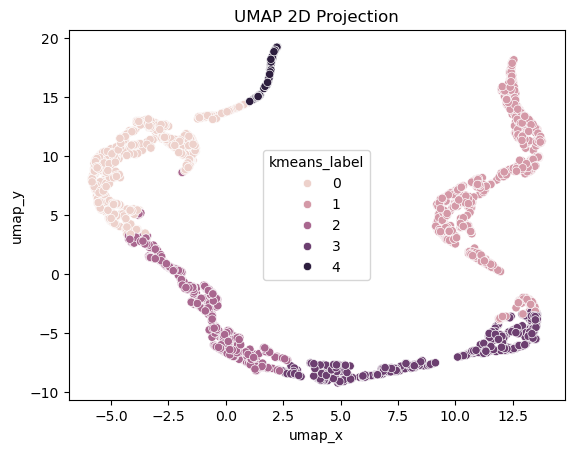

In [258]:
umap = UMAP()
X[['umap_x', 'umap_y']] = umap.fit_transform(X_norm)
sns.scatterplot(data=X, x='umap_x', y='umap_y', hue='kmeans_label')
plt.title("UMAP 2D Projection")
plt.show()

In [259]:
X['job']=X_3['job']
X['education']=X_3['education']
X['marital']=X_3['marital']

In [260]:
# Summarize clusters by selected attributes
for label in sorted(X['kmeans_label'].unique()):
    cluster = X[X['kmeans_label'] == label]
    job = cluster['job'].value_counts().idxmax()
    job_pct = round(cluster['job'].value_counts().max() / len(cluster) * 100, 1)
    education = cluster['education'].value_counts().idxmax()
    marital = cluster['marital'].value_counts().idxmax()
    age_median = cluster['age'].median()
    balance_median = cluster['balance'].median()
    print(f"Cluster {label} || median age: {age_median}")
    print(f"          || Median balance: €{balance_median}")
    print(f"          || Predominantly {education} educated")
    print(f"          || Jobs as {job} ({job_pct}%)")
    print(f"          || Mostly {marital}")
    print("\n")

Cluster 0 || median age: 36.0
          || Median balance: €35.5
          || Predominantly secondary educated
          || Jobs as management (21.4%)
          || Mostly married


Cluster 1 || median age: 38.0
          || Median balance: €2850.0
          || Predominantly tertiary educated
          || Jobs as management (29.7%)
          || Mostly married


Cluster 2 || median age: 36.0
          || Median balance: €420.0
          || Predominantly secondary educated
          || Jobs as blue-collar (22.3%)
          || Mostly married


Cluster 3 || median age: 38.0
          || Median balance: €934.0
          || Predominantly secondary educated
          || Jobs as management (22.2%)
          || Mostly married


Cluster 4 || median age: 39.0
          || Median balance: €-394.0
          || Predominantly secondary educated
          || Jobs as blue-collar (25.0%)
          || Mostly married




### New approach: KMeans -> Supervised Model -> SHAP -> Re-run Dendrogram

This dendrogram is quite complicated. Let's try a different approach involving the following steps:
1. Reduce dimensionality of the datset
1. Determine optimal clusters with an elbow plot
1. Run the KMeans clustering algorithm and use its labels as target outputs
1. Apply the RandomForestClassifier supervised model to predict cluster labels based on the features
1. Generate SHAP values to surface the most influential features for predicting the cluster labels
1. Filter dataset to only include the top SHAP-ranked features
1. Re-run the dendrogram process to visualize the relationship between these top features

#### 1. Reduce dimensionality

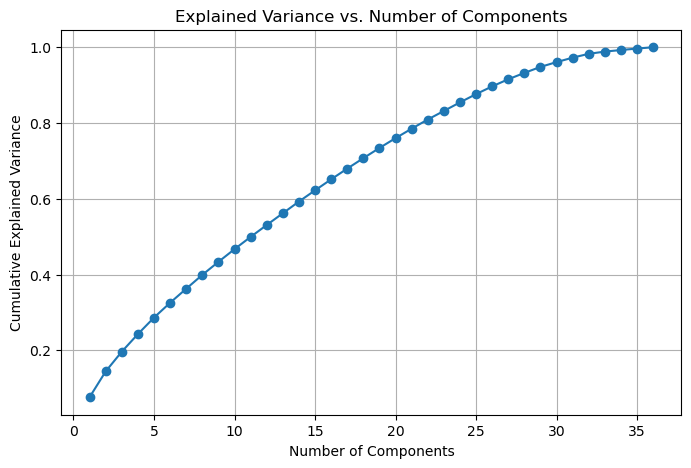

In [51]:
pca=PCA(random_state=seed)
pca.fit(X_scaled)

# calculate explained variance
explained_variance=pca.explained_variance_ratio_
cumulative_variance=explained_variance.cumsum()

# plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)

plt.savefig('../figs/2_l3_explainedVariance.png')
plt.savefig('../figs/2_l3_explainedVariance.pdf')
plt.savefig('../figs/2_l3_explainedVariance.jpg')

plt.show()

#### 2. Elbow Plot

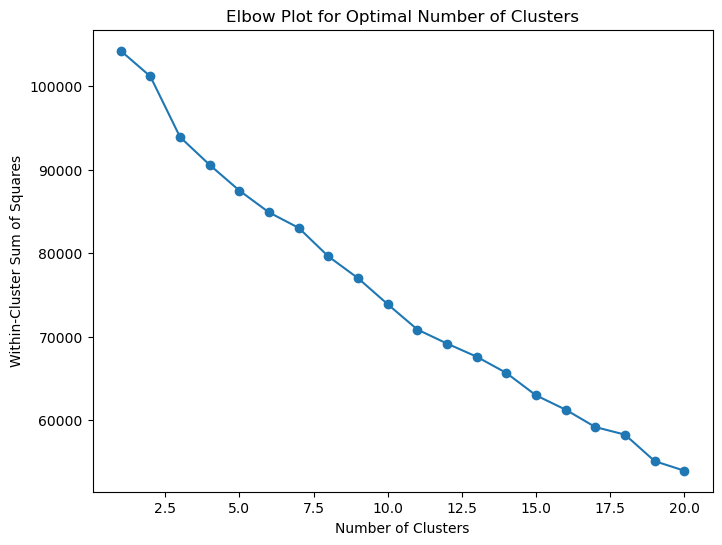

In [52]:
wcss=[] # within-cluster sum of squares
range_=range(1,21)

for i in range_:
    kmeans=KMeans(n_clusters=i,random_state=seed)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
# plot elbow plot
plt.figure(figsize=(8,6))
plt.plot(range_,wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.title('Elbow Plot for Optimal Number of Clusters')

plt.savefig('../figs/2_l3_elbow.png')
plt.savefig('../figs/2_l3_elbow.pdf')
plt.savefig('../figs/2_l3_elbow.jpg')

plt.show()

#### 1. Run Clustering and Obtain Cluster Labels

In [78]:
# this will give each data point a cluster label
n_clusters=10
kmeans=KMeans(n_clusters=n_clusters,random_state=seed)
X_encoded['cluster_label']=kmeans.fit_predict(X_scaled)
X_encoded.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,cluster_label
83,59,2343,5,1042,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,3
86,56,45,5,1467,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,3
87,41,1270,5,1389,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1
129,55,2476,5,579,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,3
168,54,184,5,673,2,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,2


#### 2. Train a Supervised Model to Predict Cluster Labels

In [79]:
# use cluster_label as the target variable to train a supervised model
X_features=X_encoded.drop(columns=['cluster_label'])
y_labels=X_encoded['cluster_label']

# split data
X_train,X_test,y_train,y_test=train_test_split(
    X_features,y_labels,test_size=0.2,random_state=seed)

# train model
model=RandomForestClassifier(random_state=seed)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=4769)

#### 3. Use SHAP to Identify Important Features

<Figure size 1500x600 with 0 Axes>

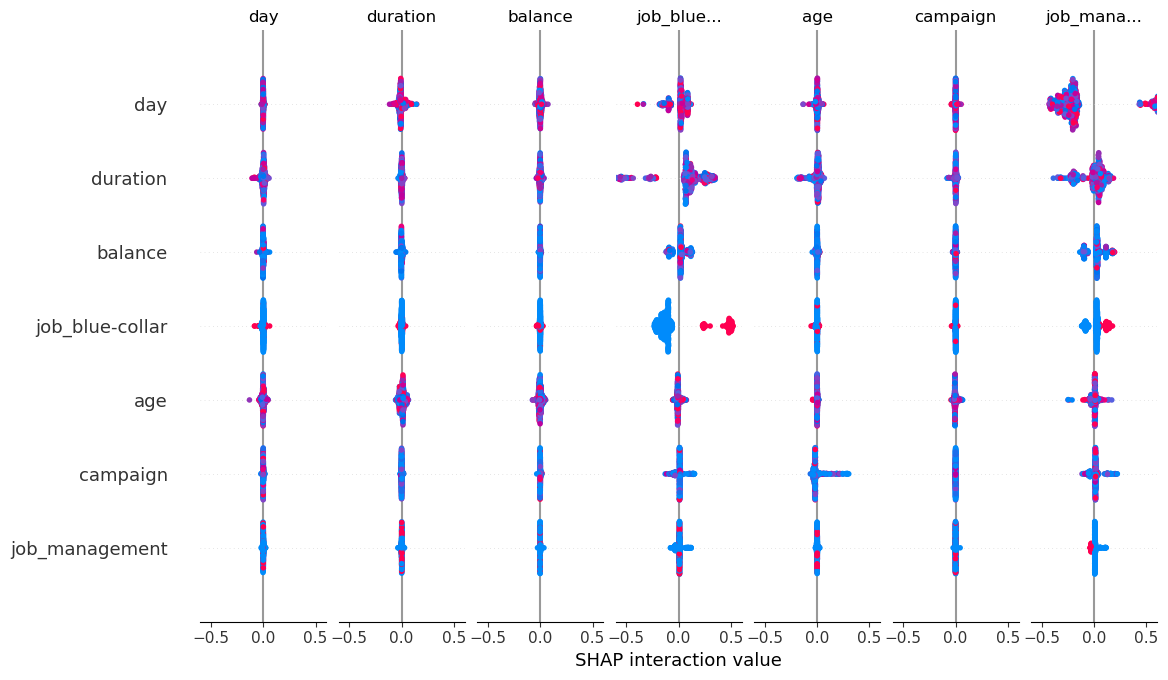

<Figure size 640x480 with 0 Axes>

In [81]:
# initialize SHAP explainer on the RFC model
explainer=shap.TreeExplainer(model)

# generate SHAP values
shap_values=explainer.shap_values(X_test)

# plot featuer importance
plt.figure(figsize=(15,6))
plt.tight_layout()
shap.summary_plot(shap_values,X_test,title=f'SHAP Plot with {n_clusters} Clusters')

plt.savefig('../figs/2_l3_shap.png')
plt.savefig('../figs/2_l3_shap.pdf')
plt.savefig('../figs/2_l3_shap.jpg')

plt.show()

#### 4. Filter for Top Features and Rerun Dendrogram

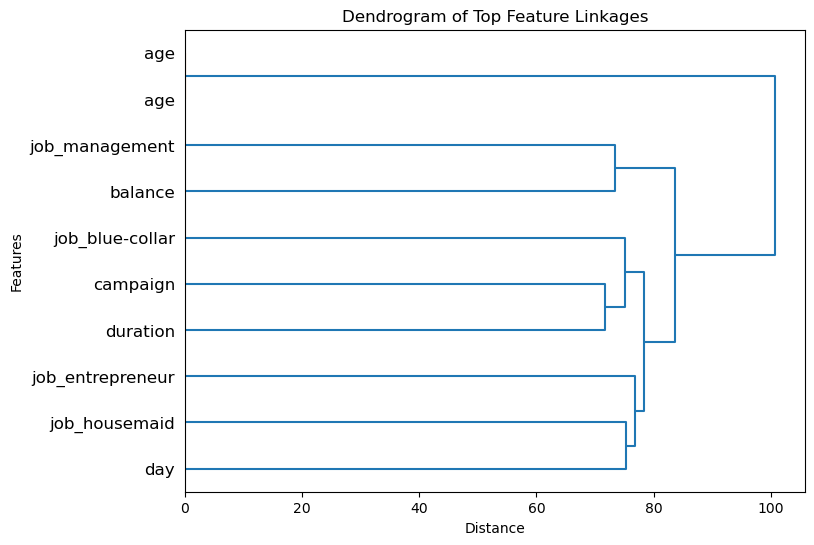

In [87]:
# extract top features
top_num=10 # top ten
top_features=X_test.columns[np.argsort(np.abs(shap_values).mean(axis=0)).flatten()[-top_num:]]
X_top_features=X_scaled[top_features] # filter datset for only top features
X_top_features_t=X_top_features.T # transpose for dendrogram

plt.figure(figsize=(8, 6))
links=linkage(X_top_features_t,method='ward',metric='euclidean')
dendrogram(
    links,
    labels=top_features,
    orientation='right',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.ylabel('Features')
plt.xlabel('Distance')
plt.title('Dendrogram of Top Feature Linkages')

plt.savefig('../figs/2_l3_dendrogram_b.png')
plt.savefig('../figs/2_l3_dendrogram_b.pdf')
plt.savefig('../figs/2_l3_dendrogram_b.jpg')

plt.show()

### Unsupervised Learning: Clustering

In [272]:
# define and dummify
X=df[df['y']=='yes'].copy() # use full dataset and filter X
X=pd.get_dummies(X,drop_first=True)

# normalize dataset
X_norm=pd.DataFrame(normalize(X),columns=X.columns)
X_norm.shape

(2896, 36)

In [273]:
X_norm.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,0.023002,0.913471,0.001949,0.406247,0.000390,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000390,0.0,0.0
1,0.038127,0.030638,0.003404,0.998796,0.000681,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000681,0.0,0.0
2,0.021779,0.674623,0.002656,0.737835,0.000531,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000531,0.0,0.0
3,0.021625,0.973501,0.001966,0.227648,0.000393,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000393,0.0,0.0
4,0.077164,0.262929,0.007145,0.961690,0.002858,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001429,0.0,0.0


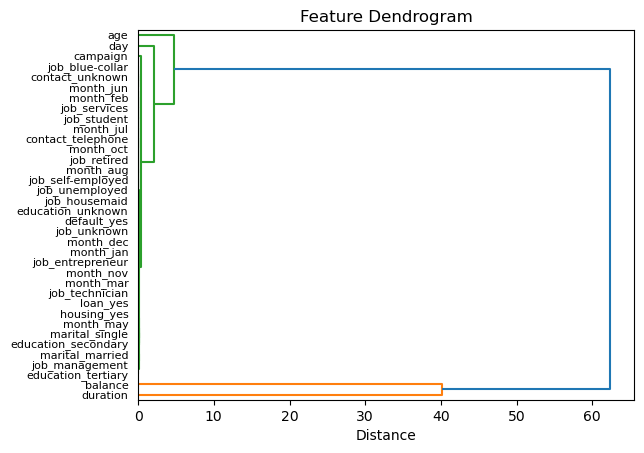

In [274]:
links=linkage(X_norm.T,method='ward',metric='euclidean')
dendrogram(links,labels=X_norm.columns,orientation='right',distance_sort='descending')
plt.xlabel('Distance')
plt.title('Feature Dendrogram')
plt.show()

In [275]:
list_cols=['age','day','balance','duration','campaign']

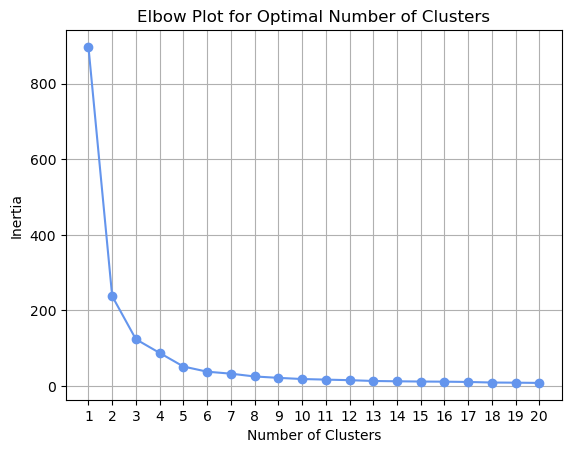

In [276]:
wcss=[] # within-cluster sum of means i.e., inertia
range_=range(1,21)

for i in range_:
    kmeans = KMeans(n_clusters=i, random_state=seed).fit(X_norm)
    wcss.append(kmeans.inertia_)

plt.plot(range_, wcss, marker='o',color='cornflowerblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Optimal Number of Clusters')
plt.grid('minor')
plt.xticks(range_)
         
# plt.savefig('../figs/2_l3_elbow.png')
# plt.savefig('../figs/2_l3_elbow.pdf')
# plt.savefig('../figs/2_l3_elbow.jpg')
         
plt.show()

#### Other

In [277]:
n_clusters=4
kmeans=KMeans(n_clusters=n_clusters,random_state=seed)
X_norm['cluster_labels']=kmeans.fit_predict(X_norm)

X_norm['cluster_labels'].value_counts()

cluster_labels
1    1008
0     656
2     622
3     610
Name: count, dtype: int64

In [279]:
X_norm['cluster_labels']

0       1
1       0
2       3
3       1
4       2
       ..
2891    3
2892    1
2893    1
2894    1
2895    3
Name: cluster_labels, Length: 2896, dtype: int32

In [283]:
X['cluster_labels']=X_norm['cluster_labels']
df_l3=df.copy()
df_l3['cluster_labels']=X['cluster_labels']
cluster_summary=df_l3.describe()
cluster_summary

,age,balance,day,duration,campaign,cluster_labels
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,73.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175,1.438356
std,9.641776,2903.769716,8.278127,259.366498,3.239051,1.092732
min,19.000000,-8019.000000,1.000000,0.000000,1.000000,0.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000,1.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000,2.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,3.000000


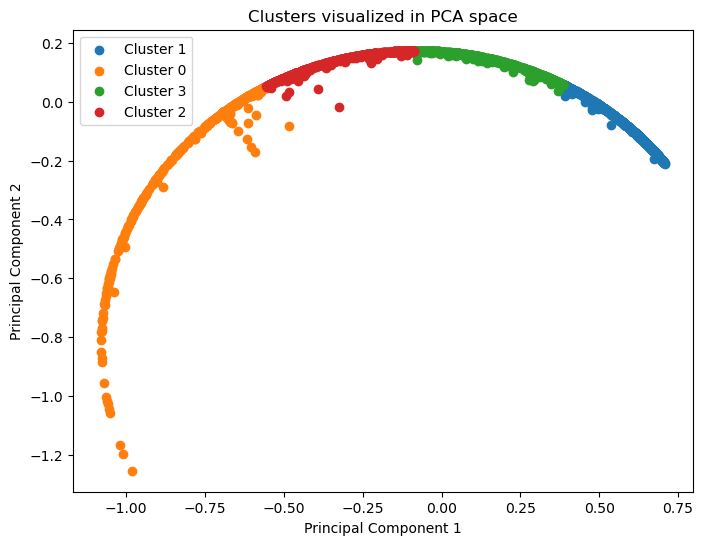

In [290]:
pca=PCA(n_components=2)
X_norm_pca=pca.fit_transform(X_norm.drop('cluster_labels',axis=1))

# Create a DataFrame to plot
pca_df = pd.DataFrame(X_norm_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = X_norm['cluster_labels']

# Plot the clusters
plt.figure(figsize=(8, 6))
for cluster in pca_df['Cluster'].unique():
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], label=f'Cluster {cluster}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.title('Clusters visualized in PCA space')
plt.show()

KeyError: 'cluster_labels'

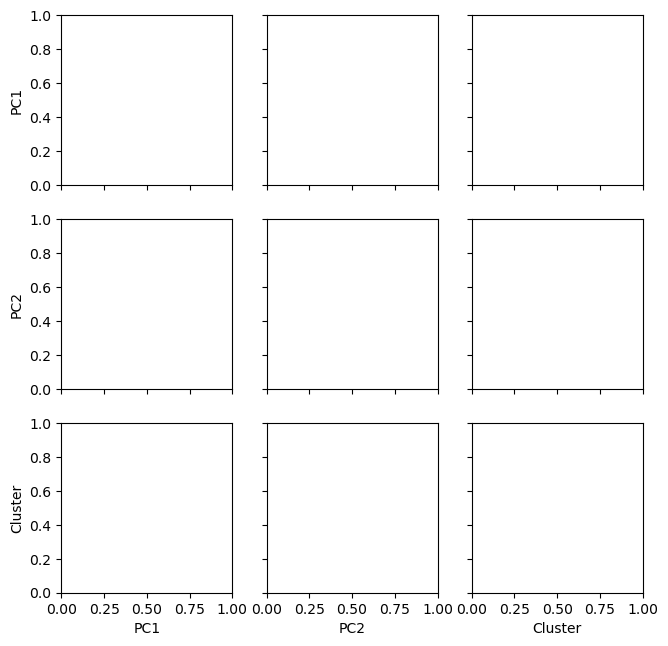

In [294]:
sns.pairplot(pca_df, hue='cluster_labels', palette='viridis')
plt.show()

In [323]:
# Load the model
model=joblib.load('../joblib/l2_model.pkl')

Prepare data for the full dataset run:

In [332]:
# Dummify binary columns
binary_mappings = {
    'default': {'yes': 1, 'no': 0},
    'housing': {'yes': 1, 'no': 0},
    'loan': {'yes': 1, 'no': 0}
}

# Select only the subscribers
X=df.copy()
X.loc[:, 'y'] = y  # Temporarily add y to filter out non-subscribers
X = X[X['y'] == 1]  # Filter out non-subscribers
X = X.drop('y', axis=1)  # Drop y after filtering

# Map binary columns
if X['default'].isna().sum() != 0:  # In case the cell runs more than once
    for column, mapping in binary_mappings.items():
        X[column] = X[column].map(mapping)
        
# Encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [333]:
# Generate feature importances
importances = model.feature_importances_

# Create a DataFrame for feature importances
feature_df = pd.DataFrame({'feature': X_encoded.columns, 'importance': importances})

# Plot sorted feature importances
feature_df_sorted = feature_df.sort_values('importance', ascending=False)
feature_df_sorted.plot.barh(y='importance', x='feature', figsize=(8, 8))
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.show()

# Display top 10 features by importance
top_10_features = feature_df_sorted.head(10)
print(top_10_features)

ValueError: All arrays must be of the same length

In [327]:
X_encoded.shape

(2896, 36)

In [329]:
X_encoded.head()

,age,balance,day,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
83,59,2343,5,1042,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
86,56,45,5,1467,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
87,41,1270,5,1389,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
129,55,2476,5,579,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
168,54,184,5,673,2,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [330]:
feature_df=pd.DataFrame({'feature':X_encoded.columns,'importance':importances})

feature_df.sort_values('importance').plot.barh(y='importance',x='feature',figsize=(8,8))
plt.title('Feature Importances from RandomForestClassifier')

feature_df.sort_values('importance',ascending=False)[:,10]

ValueError: All arrays must be of the same length

#### Prepare dataset for unsupervised learning

In [489]:
# define and dummify
X=df[[col for col in df.columns if col != 'y']]
y=df['y'].copy()

def yes_no_to_binary(value):
    if value=='yes':
        return 1
    elif value=='no':
        return 0
    return value

y=y.map(yes_no_to_binary)
X_fix=X.map(yes_no_to_binary)

X=pd.get_dummies(X_fix,drop_first=True)

# scale dataset
scaler=StandardScaler()
X_scale=pd.DataFrame(scaler.fit_transform(X),columns=X.columns)
X_scale.head()

,age,default,balance,housing,loan,day,duration,campaign,job_blue-collar,job_entrepreneur,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,1.810415,-0.143675,0.299174,0.815179,-0.457772,-1.3309,0.023811,-0.581096,-0.553592,-0.190797,...,-0.387196,-0.018031,-0.24677,-0.174042,-0.435624,-0.366384,-0.080572,1.398555,-0.314389,-0.044766
1,0.358382,-0.143675,-0.428854,0.815179,-0.457772,-1.3309,-0.400305,-0.581096,-0.553592,-0.190797,...,-0.387196,-0.018031,-0.24677,-0.174042,-0.435624,-0.366384,-0.080572,1.398555,-0.314389,-0.044766
2,-0.782501,-0.143675,-0.438152,0.815179,2.184492,-1.3309,-0.689474,-0.581096,-0.553592,5.241159,...,-0.387196,-0.018031,-0.24677,-0.174042,-0.435624,-0.366384,-0.080572,1.398555,-0.314389,-0.044766
3,0.669532,-0.143675,0.079802,0.815179,-0.457772,-1.3309,-0.627785,-0.581096,1.806386,-0.190797,...,-0.387196,-0.018031,-0.24677,-0.174042,-0.435624,-0.366384,-0.080572,1.398555,-0.314389,-0.044766
4,-0.782501,-0.143675,-0.438497,-1.226725,-0.457772,-1.3309,-0.219092,-0.581096,-0.553592,-0.190797,...,-0.387196,-0.018031,-0.24677,-0.174042,-0.435624,-0.366384,-0.080572,1.398555,-0.314389,-0.044766


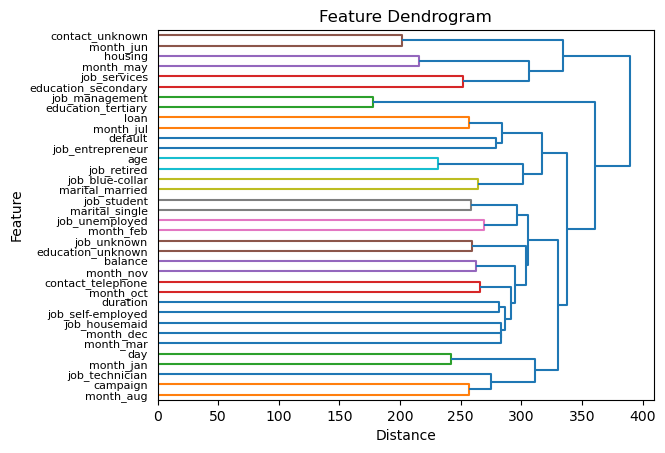

In [490]:
links=linkage(X_scale.T,method='ward',metric='euclidean')
dendrogram(links,labels=X_scale.columns,orientation='right',distance_sort='descending')
plt.xlabel('Distance')
plt.title('Feature Dendrogram')
plt.ylabel('Feature')

# plt.savefig('../figs/2_l3_dendrogram.pdf')
# plt.savefig('../figs/2_l3_dendrogram.jpg')
# plt.savefig('../figs/2_l3_dendrogram.png')

plt.show()

In [492]:
pca=PCA(n_components=6)
pca.fit(X_scale)

print(pca.explained_variance_)

[2.68028987 2.30012859 1.98176132 1.64745158 1.47651798 1.39055969]


In [493]:
print(pca.components_)

[[ 0.1018947  -0.00660525  0.09804956 -0.29795703 -0.02451331  0.09746349
  -0.02815842  0.08426574 -0.26098361  0.03124069  0.04052668  0.365934
   0.04152508  0.05330921 -0.14590604 -0.01120512 -0.00244889  0.00757352
   0.02057197 -0.00444995  0.00102677 -0.34675976  0.43055068 -0.00456875
   0.07715766 -0.31449238  0.26891788  0.00830596  0.05242389  0.06143412
   0.09879441 -0.08632019  0.04854349 -0.34447358  0.1187888   0.01780188]
 [-0.42740034 -0.00211059 -0.0257337   0.14381571 -0.06690033 -0.01500429
   0.04531899 -0.06704672 -0.11189436 -0.03628544 -0.1118779   0.16341961
  -0.20924684  0.00125509  0.00265332  0.17397602  0.05932795 -0.00209397
  -0.05163127 -0.48923265  0.52585754 -0.06333693  0.2244032  -0.05319032
  -0.11479949  0.01647222 -0.07854746  0.00374002  0.03352907  0.03793488
  -0.10916115 -0.10186947  0.0215893   0.18123803 -0.02034346 -0.01136239]
 [ 0.11248334 -0.03603116  0.09385822  0.13379742 -0.13038596 -0.1919795
   0.00352192 -0.06420589  0.06904017  

In [494]:
print(pca.explained_variance_ratio_)

[0.07445064 0.06389086 0.05504755 0.0457614  0.04101336 0.03862569]


In [500]:
pca3=PCA(n_components=3)
pca3.fit(X_scale)
# print(pca3.components_)
# print(pca3.explained_variance_ratio_)
Xpca3 = pca3.transform(X_scale)
regression_model_pca = RandomForestClassifier(random_state=seed)
regression_model_pca.fit(Xpca3, y)
regression_model_pca.score(Xpca3, y)

y_pred=regression_model_pca.predict(Xpca3)
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37104
           1       1.00      1.00      1.00      2896

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



Model Score: 0.99995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37104
           1       1.00      1.00      1.00      2896

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



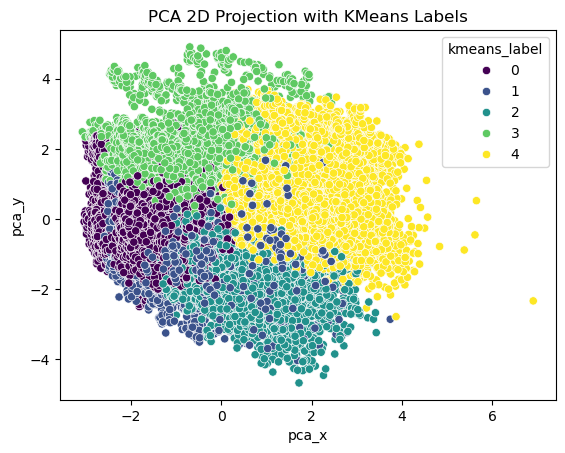

In [507]:
# Perform PCA with 3 components
pca3 = PCA(n_components=5)
Xpca3 = pca3.fit_transform(X_scale)  # Fit and transform in one step

# Train a RandomForestClassifier on the PCA-transformed data
regression_model_pca = RandomForestClassifier(random_state=seed)
regression_model_pca.fit(Xpca3, y)
print("Model Score:", regression_model_pca.score(Xpca3, y))

# Get predictions and classification report
y_pred = regression_model_pca.predict(Xpca3)
print(classification_report(y, y_pred))

# Perform KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=seed)
kmeans_labels = kmeans.fit_predict(Xpca3)

# Add the PCA components and labels to X
X['pca_x'], X['pca_y'], X['pca_z'] = Xpca3[:, 0], Xpca3[:, 1], Xpca3[:, 2]
X['kmeans_label'] = kmeans_labels

# Plot the PCA 2D projection with labels
sns.scatterplot(data=X, x='pca_x', y='pca_y', hue='kmeans_label', palette="viridis")
plt.title("PCA 2D Projection with KMeans Labels")
plt.show()

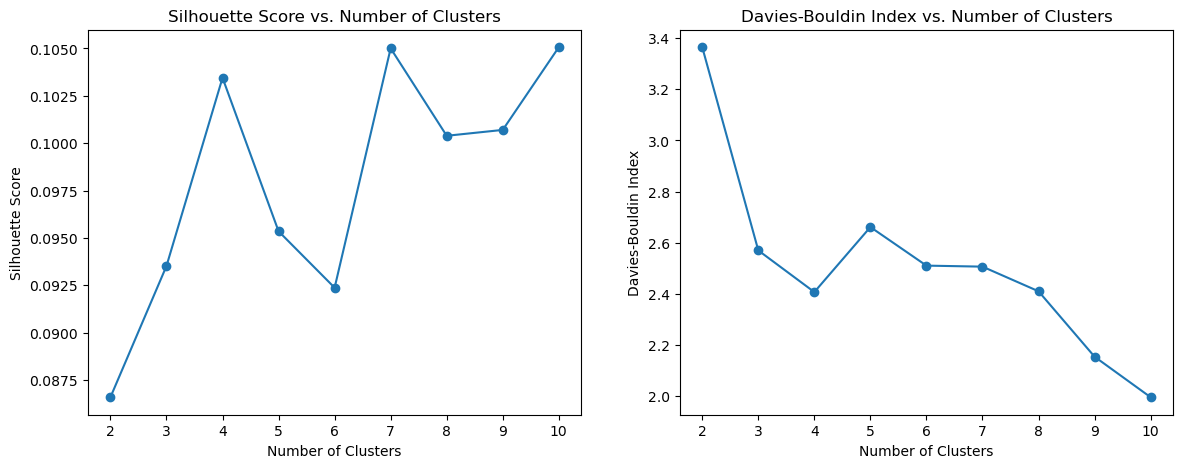

In [510]:
silhouette_scores = []
davies_bouldin_scores = []
k_values = range(2, 11)
model_list=[KMeans(random_state=seed),
           DBSCAN(n_jobs=-1),
           SpectralClustering(random_state=seed),
           MeanShift(n_jobs=-1)]

for k in k_values:
    for model_ in model_list:
        model_ = KMeans(n_clusters=k, random_state=seed)
        labels = kmeans.fit_predict(X_scale)
        silhouette_scores.append(silhouette_score(X_scale, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_scale, labels))

# Plot the silhouette and Davies-Bouldin scores
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.subplot(1, 2, 2)
plt.plot(k_values, davies_bouldin_scores, marker='o')
plt.title("Davies-Bouldin Index vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")

plt.show()

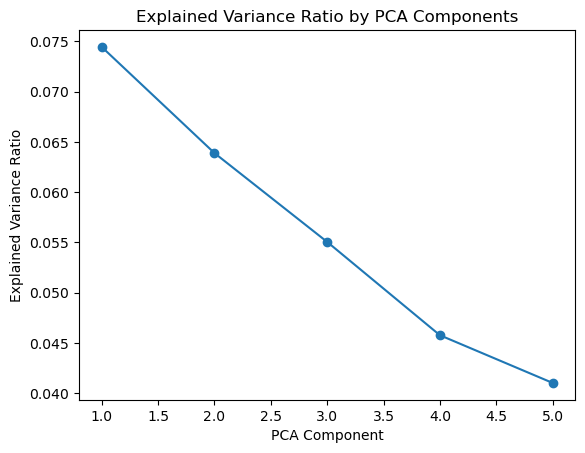

In [515]:
plt.plot(range(1, len(pca3.explained_variance_ratio_) + 1), pca3.explained_variance_ratio_, marker='o')
plt.title("Explained Variance Ratio by PCA Components")
plt.xlabel("PCA Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

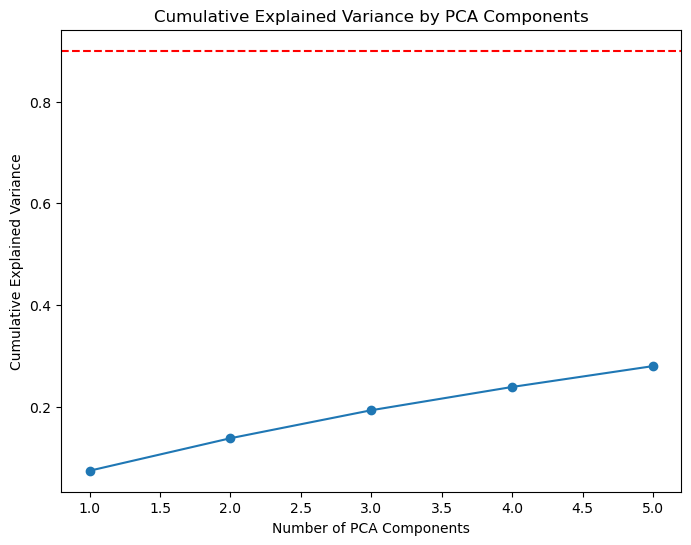

In [516]:
cumulative_explained_variance = np.cumsum(pca3.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.axhline(y=0.9, color='r', linestyle='--')  # 90% variance threshold line
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

##### Explore different clustering algorithms

Evaluating model: KMeans
Evaluating model: DBSCAN
Evaluating model: MeanShift
Evaluating model: GaussianMixture
GaussianMixture found only one cluster, skipping score calculation.
Evaluating model: AgglomerativeClustering
Evaluating model: HDBSCAN


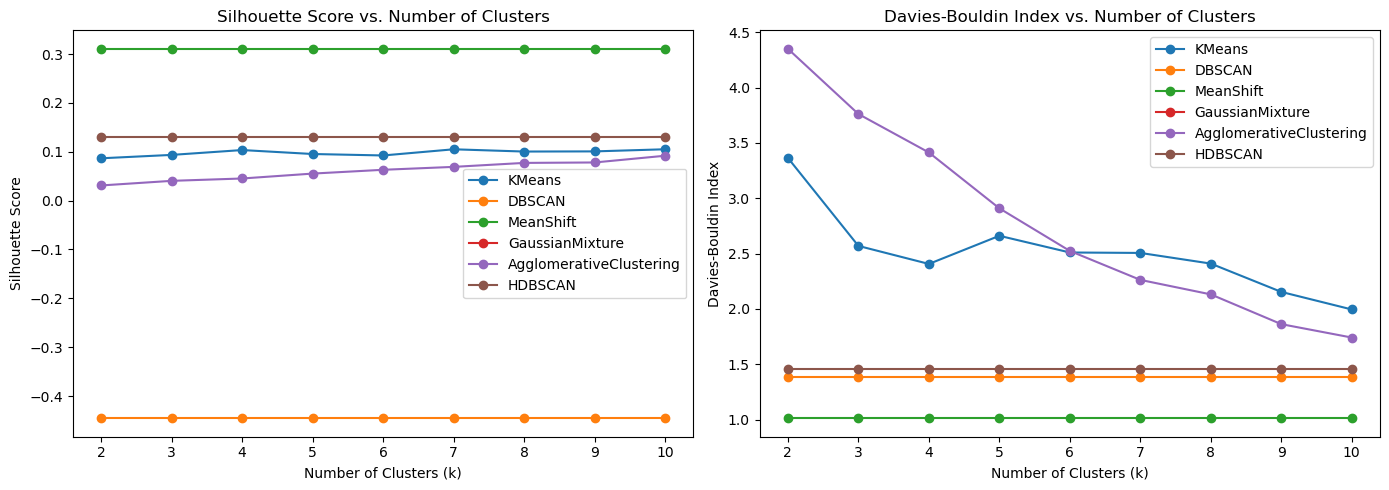

In [525]:
# Define range for k (number of clusters) where applicable
k_values = range(2, 11)
model_list = [KMeans(random_state=seed),
              DBSCAN(n_jobs=-1),
              # SpectralClustering(random_state=seed),
              MeanShift(n_jobs=-1),
              GaussianMixture(random_state=seed),
              AgglomerativeClustering(),
              HDBSCAN(n_jobs=-1)]

# Initialize storage for scores
silhouette_scores = {model.__class__.__name__: [] for model in model_list}
davies_bouldin_scores = {model.__class__.__name__: [] for model in model_list}

# Evaluate models
for model_ in model_list:
    model_name = model_.__class__.__name__
    print(f"Evaluating model: {model_name}")
    
    if model_name in ["KMeans", "SpectralClustering", "AgglomerativeClustering"]:
        # For models requiring n_clusters, loop over k values
        for k in k_values:
            model_.set_params(n_clusters=k)
            labels = model_.fit_predict(X_scale)
            # Check if the model found more than one cluster
            if len(set(labels)) > 1:
                silhouette_scores[model_name].append(silhouette_score(X_scale, labels))
                davies_bouldin_scores[model_name].append(davies_bouldin_score(X_scale, labels))
            else:
                print(f"{model_name} with k={k} found only one cluster, skipping score calculation.")
                silhouette_scores[model_name].append(None)
                davies_bouldin_scores[model_name].append(None)
    else:
        # For models that don't require n_clusters, fit once
        labels = model_.fit_predict(X_scale)
        if len(set(labels)) > 1:
            silhouette_scores[model_name] = [silhouette_score(X_scale, labels)] * len(k_values)
            davies_bouldin_scores[model_name] = [davies_bouldin_score(X_scale, labels)] * len(k_values)
        else:
            print(f"{model_name} found only one cluster, skipping score calculation.")
            silhouette_scores[model_name] = [None] * len(k_values)
            davies_bouldin_scores[model_name] = [None] * len(k_values)

# Plot the scores for each model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name in silhouette_scores.keys():
    axes[0].plot(k_values, silhouette_scores[model_name], marker='o', label=model_name)
    axes[1].plot(k_values, davies_bouldin_scores[model_name], marker='o', label=model_name)

axes[0].set_title("Silhouette Score vs. Number of Clusters")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")
axes[0].legend()

axes[1].set_title("Davies-Bouldin Index vs. Number of Clusters")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Davies-Bouldin Index")
axes[1].legend()

plt.tight_layout()

plt.savefig('../figs/2_l3_algorithmperformance.pdf')
plt.savefig('../figs/2_l3_algorithmperformance.jpg')
plt.savefig('../figs/2_l3_algorithmperformance.png')

plt.show()

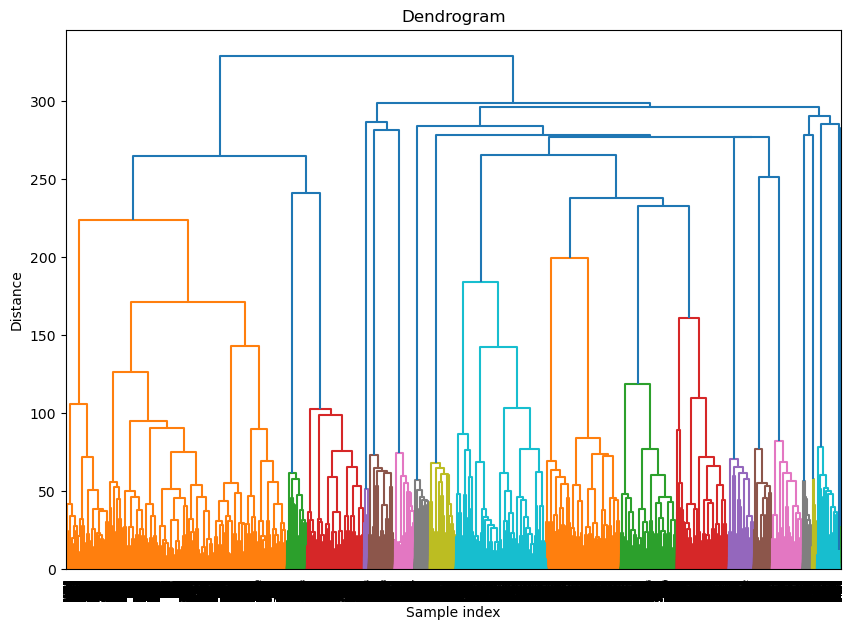

In [527]:
# Linkage matrix
Z = linkage(X_scale, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.savefig('../figs/2_l3_dendrogramfull.pdf')
plt.savefig('../figs/2_l3_dendrogramfull.jpg')
plt.savefig('../figs/2_l3_dendrogramfull.png')

plt.show()

In [532]:
from scipy.spatial.distance import cdist
from kneed import KneeLocator

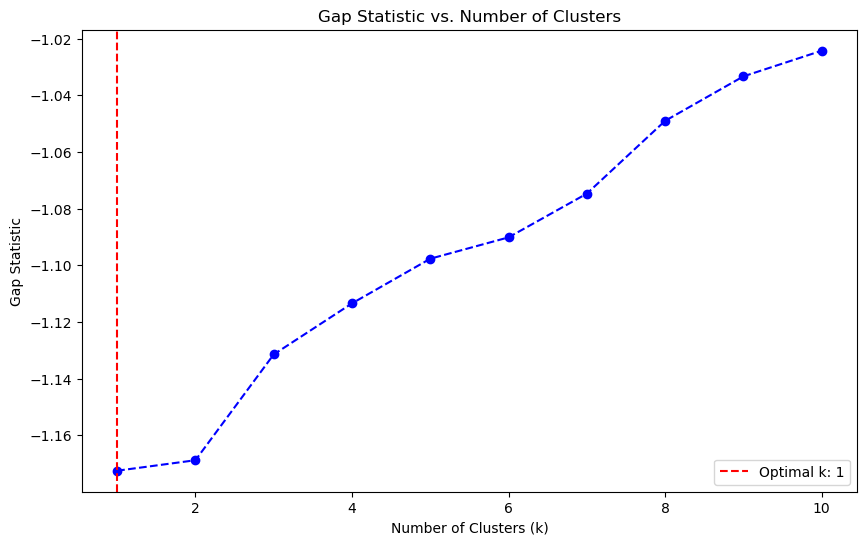

Optimal number of clusters according to Gap Statistic: 1


In [533]:
def calculate_gap_statistic(X, max_clusters=10, n_refs=20, random_state=42):
    gaps = []
    s_k = []
    n_clusters_range = range(1, max_clusters + 1)
    
    # Reference dispersion values
    for k in n_clusters_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state).fit(X)
        Wk = np.log(np.mean(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1)))
        
        # Reference Wk
        ref_disps = np.zeros(n_refs)
        for i in range(n_refs):
            random_data = np.random.random_sample(size=X.shape)
            kmeans_ref = KMeans(n_clusters=k, random_state=random_state).fit(random_data)
            ref_disps[i] = np.log(np.mean(np.min(cdist(random_data, kmeans_ref.cluster_centers_, 'euclidean'), axis=1)))
        
        gap = np.mean(ref_disps) - Wk
        sdk = np.sqrt(np.mean((ref_disps - np.mean(ref_disps))**2)) * np.sqrt(1 + 1 / n_refs)
        
        gaps.append(gap)
        s_k.append(sdk)
    
    return n_clusters_range, gaps, s_k

# Calculate gap statistic
n_clusters_range, gaps, s_k = calculate_gap_statistic(X_scale, max_clusters=10)

# Plot the gap statistic
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, gaps, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic vs. Number of Clusters')

# Find the optimal number of clusters using the "knee" point
kn = KneeLocator(n_clusters_range, gaps, curve='convex', direction='decreasing')
optimal_k = kn.knee
plt.axvline(optimal_k, linestyle='--', color='r', label=f'Optimal k: {optimal_k}')
plt.legend()
plt.show()

print(f"Optimal number of clusters according to Gap Statistic: {optimal_k}")

In [537]:
# Step 1: Reduce data dimensions with t-SNE or UMAP
tsne = TSNE(n_components=3, random_state=seed)
print('Reducing X')
X_reduced = tsne.fit_transform(X_scale)  # Replace X_scale with your scaled data

# Step 2: Apply clustering on reduced data
kmeans = KMeans(n_clusters=3, random_state=seed)  # Adjust the number of clusters if needed
print('Creating cluster labels')
cluster_labels = kmeans.fit_predict(X_reduced)

# Step 3: Train a classifier to predict cluster labels
clf = RandomForestClassifier(random_state=seed)
print('Fitting model')
clf.fit(X_scale, cluster_labels)  # Use original features as predictors

# Step 4: Calculate permutation feature importance
print('Calculating Permutation Feature Importance')
perm_importance = permutation_importance(clf, X_scale, cluster_labels, n_repeats=10, random_state=seed)

# Display feature importance
print('Displaying feature importance')
feature_importances = perm_importance.importances_mean
feature_names = X_scale.columns  # Replace with your feature names if applicable
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

Reducing X
Creating cluster labels
Fitting model
Calculating Permutation Feature Importance
Displaying feature importance
                Feature  Importance
31            month_jun    0.131995
33            month_may    0.094193
26            month_aug    0.061297
14         job_services    0.058670
22   education_tertiary    0.051230
21  education_secondary    0.050443
8       job_blue-collar    0.049980
34            month_nov    0.042442
16       job_technician    0.040245
24    contact_telephone    0.039902
20       marital_single    0.037540
9      job_entrepreneur    0.034605
28            month_feb    0.034235
12          job_retired    0.034058
4                  loan    0.029703
19      marital_married    0.028430
11       job_management    0.027095
30            month_jul    0.024628
10        job_housemaid    0.023017
1               default    0.020230
23    education_unknown    0.019903
25      contact_unknown    0.019812
13    job_self-employed    0.018238
17       job_u

In [539]:
# Step 1: Fit PCA on your scaled dataset
n_components = 3  # Start with 2 for easier visualization; adjust if necessary
pca = PCA(n_components=n_components, random_state=42)
print('Reducing dimensionality with PCA')
X_reduced = pca.fit_transform(X_scale)

# Step 2: Apply clustering on reduced data
kmeans = KMeans(n_clusters=3, random_state=seed)  # Adjust the number of clusters if needed
print('Creating cluster labels')
cluster_labels = kmeans.fit_predict(X_reduced)

# Step 3: Train a classifier to predict cluster labels
clf = RandomForestClassifier(random_state=seed)
print('Fitting model')
clf.fit(X_scale, cluster_labels)  # Use original features as predictors

# Step 4: Calculate permutation feature importance
print('Calculating Permutation Feature Importance')
perm_importance = permutation_importance(clf, X_scale, cluster_labels, n_repeats=10, random_state=seed)

# Display feature importance
print('Displaying feature importance')
feature_importances = perm_importance.importances_mean
feature_names = X_scale.columns  # Replace with your feature names if applicable
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

# Create a DataFrame for PCA loadings
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(n_components)], index=X_scale.columns)

print("PCA Loadings for each feature:")
print(loadings)

Reducing dimensionality with PCA
Creating cluster labels
Fitting model
Calculating Permutation Feature Importance
Displaying feature importance
                Feature  Importance
22   education_tertiary    0.170347
33            month_may    0.110925
25      contact_unknown    0.069645
11       job_management    0.051615
3               housing    0.031137
30            month_jul    0.028885
8       job_blue-collar    0.028102
21  education_secondary    0.026595
5                   day    0.016850
31            month_jun    0.014045
20       marital_single    0.012248
34            month_nov    0.008895
24    contact_telephone    0.008590
16       job_technician    0.008220
0                   age    0.007587
4                  loan    0.006735
19      marital_married    0.004965
26            month_aug    0.004605
2               balance    0.003662
7              campaign    0.002777
6              duration    0.002607
14         job_services    0.002270
12          job_retired    0

Silhouette Score for KMeans on PCA-reduced data: 0.32582452382542465


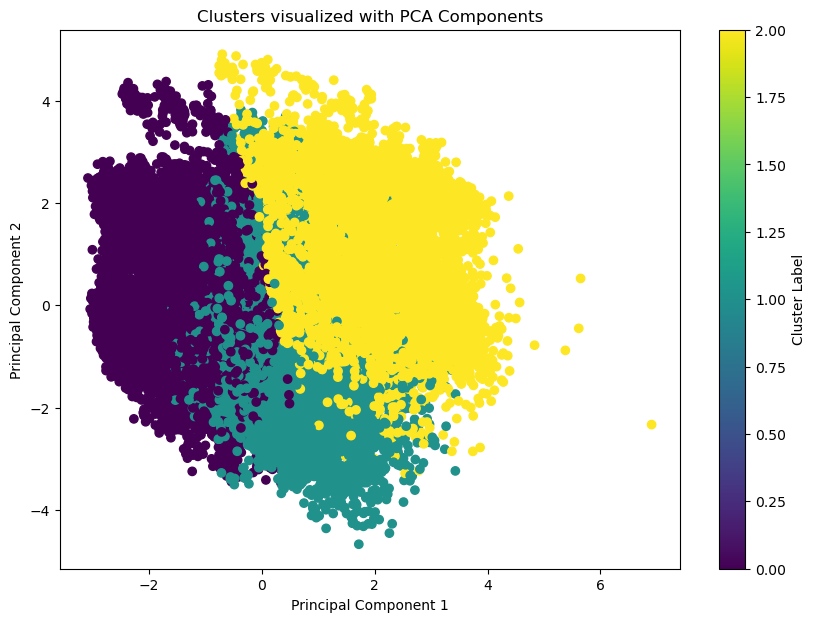

In [545]:
# Example with KMeans clustering
optimal_clusters=3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=seed)
labels = kmeans.fit_predict(X_reduced)

# Optional: Evaluate clustering with metrics (e.g., silhouette score)
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_reduced, labels)
print(f'Silhouette Score for KMeans on PCA-reduced data: {silhouette_avg}')

plt.figure(figsize=(10, 7))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', marker='o')
plt.title('Clusters visualized with PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

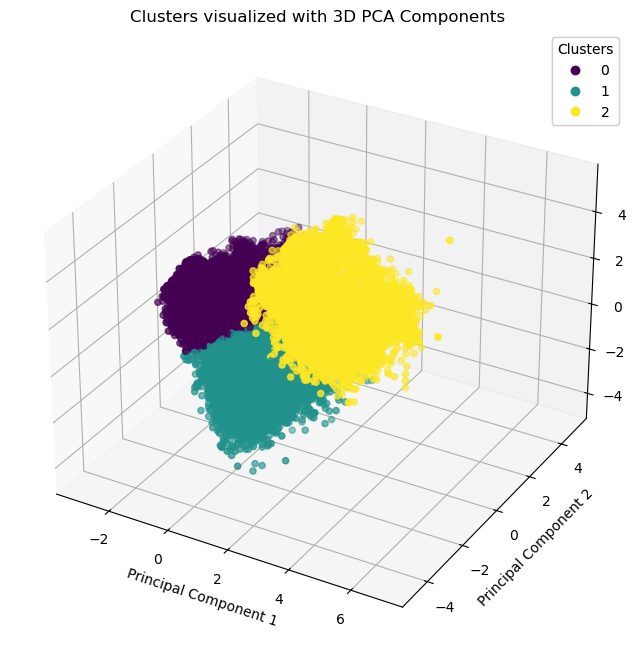

In [546]:
# Run clustering again on 3D PCA-transformed data (e.g., using KMeans)
optimal_clusters=3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=seed)
labels_3d = kmeans.fit_predict(X_reduced)

# 3D Plot of PCA components
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=labels_3d, cmap='viridis', marker='o')
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
ax.set_title('Clusters visualized with 3D PCA Components')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.show()

In [548]:
# UMAP transformation to 2D
umap_model = UMAP(n_components=2, random_state=seed)
X_umap = umap_model.fit_transform(X_scale)

# Convert to DataFrame for easier analysis
umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
umap_df = pd.concat([umap_df, pd.DataFrame(X_scale, columns=X.columns)], axis=1)

/Applications/Anaconda/anaconda3/envs/apziva/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

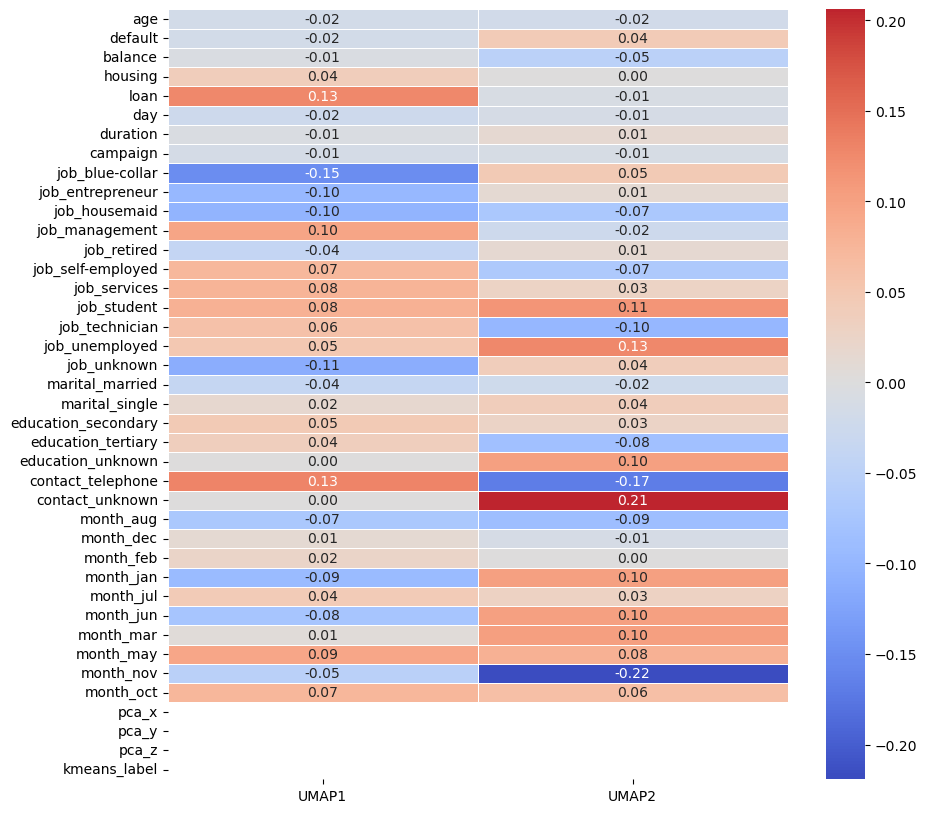

In [557]:
correlations = umap_df.corr(method='spearman').iloc[2:, :2]
correlations

plt.figure(figsize=(10,10))
sns.heatmap(data=correlations,cmap='coolwarm',center=0,linewidths=0.5,annot=True,fmt='.2f')

Unique DBSCAN cluster labels: [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 235 236 237 

/Applications/Anaconda/anaconda3/envs/apziva/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Applications/Anaconda/anaconda3/envs/apziva/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


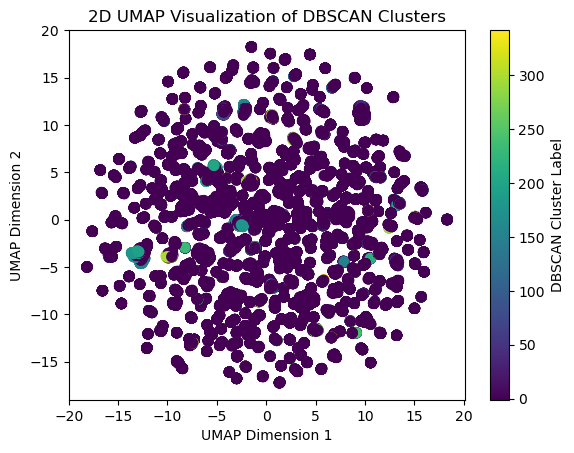

Feature importances based on supervised UMAP:
 [0.075525  0.0764125]


In [567]:
# Step 2: Initialize and fit DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust eps and min_samples based on your data
dbscan_labels = dbscan.fit_predict(X_scale)

unique_labels = np.unique(dbscan_labels)
print(f"Unique DBSCAN cluster labels: {unique_labels}")

# Initialize UMAP with supervised mode by setting `target_metric` to 'categorical'
umap_supervised = UMAP(n_components=2, random_state=42, target_metric='categorical')
X_umap_supervised = umap_supervised.fit_transform(X_scaled, y=dbscan_labels)

plt.scatter(X_umap_supervised[:, 0], X_umap_supervised[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.colorbar(label='DBSCAN Cluster Label')
plt.title("2D UMAP Visualization of DBSCAN Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

# Train-test split for the classifier
X_train, X_test, y_train, y_test = train_test_split(X_umap_supervised, dbscan_labels, test_size=0.2, random_state=42)

# Train a RandomForest classifier
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# Calculate feature importance using permutation importance
perm_importance = permutation_importance(classifier, X_test, y_test, n_repeats=10, random_state=42)
feature_importances = perm_importance.importances_mean
print("Feature importances based on supervised UMAP:\n", feature_importances)

         age  balance  duration  day  campaign  month  job  housing  \
segment                                                               
low      NaN      NaN       NaN  NaN       NaN    NaN  NaN      NaN   
med      NaN      NaN       NaN  NaN       NaN    NaN  NaN      NaN   
high     NaN      NaN       NaN  NaN       NaN    NaN  NaN      NaN   

         customer_count  
segment                  
low                   0  
med                   0  
high                  0  


/var/folders/n3/q8wb235x57n_sx2q14dsngjr0000gn/T/ipykernel_1898/4270005139.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = X_class1.groupby('segment').agg(
/var/folders/n3/q8wb235x57n_sx2q14dsngjr0000gn/T/ipykernel_1898/4270005139.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result['customer_count'] = X_class1.groupby('segment').size()


AttributeError: PathCollection.set() got an unexpected keyword argument 'hue'

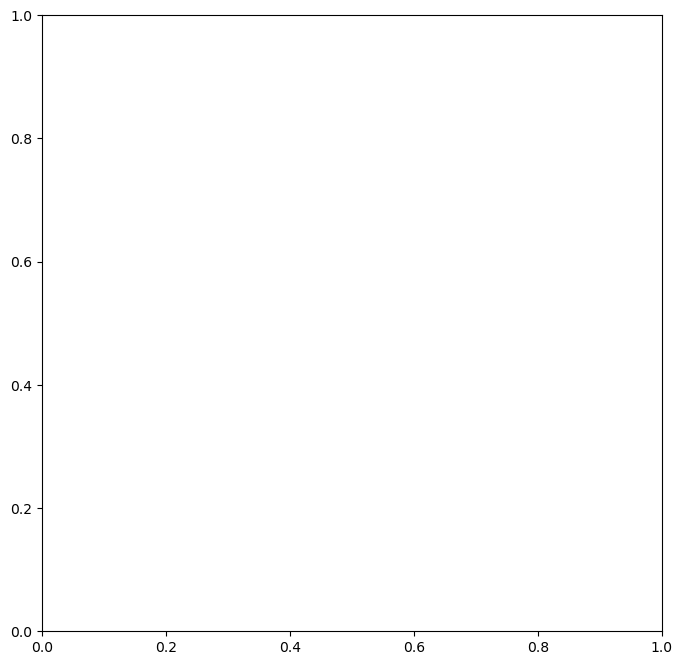

In [572]:
# prepare data
X=df.drop('y',axis=1)
y=df['y']

# handle imbalanced dataset
res=RandomOverSampler(random_state=seed)
X_res,y_res=res.fit_resample(X,y)

# detect categorical and continuous features
cat_cols = X.select_dtypes(
    include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(
    include=['int64', 'float64']).columns.tolist()

# encode features
X_encoded=pd.get_dummies(X_res,columns=cat_cols,drop_first=True)
# scale
scaler=StandardScaler()
X_encoded[num_cols]=scaler.fit_transform(X_encoded[num_cols])

# train RandomForestClassifier, prioritize recall for class 1
model=RandomForestClassifier(class_weight='balanced',random_state=seed)
model.fit(X_encoded,y_res)
y_pred_proba=model.predict_proba(X_encoded)[:,1]

# segment customers based on predicted probabilities
# define bins for segmentation and create segments
bins=[0,0.4,0.7,1]
labels=['low','med','high']
segments=pd.cut(y_pred_proba,bins=bins,labels=labels)
X_res['segment']=segments
X_res['prediction_score']=y_pred_proba

# filter data for class 1 and agg stats by segment
X_class1=X_res[y_res==1]

# define custom mode function for agg categorical columns
def custom_mode(series):
    if not series.empty:
        return series.mode().iloc[0]
    else:
        return np.nan

# Aggregate statistics for the 'high', 'medium', 'low' segments within class 1
result = X_class1.groupby('segment').agg(
    age=('age', 'mean'),
    balance=('balance', 'median'),
    duration=('duration', 'mean'),
    day=('day', 'median'),
    campaign=('campaign', 'median'),
    month=('month', custom_mode),
    job=('job', custom_mode),
    housing=('housing', custom_mode)
)
# Add a customer count per segment
result['customer_count'] = X_class1.groupby('segment').size()
print(result)

plt.figure(figsize=(8,8))
plt.scatter(x=X_class1['balance'],y=X_class1['month'],hue=X_class1['segment'],size=X_class1['duration'])
plt.title('Visualizing Customer Segments in 2D Scatter Plot')
plt.xlabel('Balance')
plt.ylabel('Month')
plt.show()

In [511]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scale)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scale[:, 0], y=X_scale[:, 1], hue=dbscan_labels, palette="viridis")
plt.title("DBSCAN Clustering on PCA Data")
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

<Figure size 800x600 with 0 Axes>

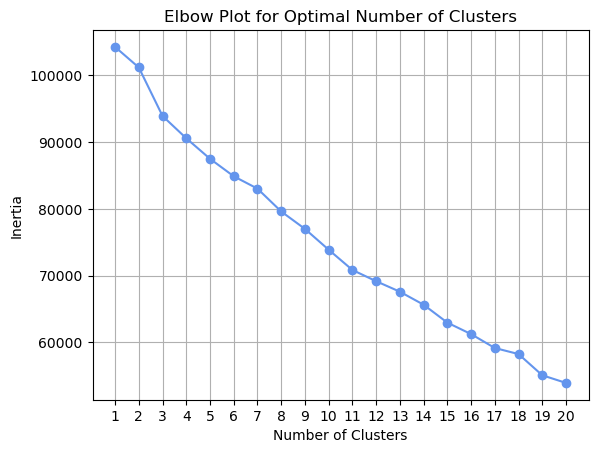

In [473]:
wcss=[] # within-cluster sum of means i.e., inertia
range_=range(1,21)

for i in range_:
    kmeans = KMeans(n_clusters=i, random_state=seed).fit(X_scale)
    wcss.append(kmeans.inertia_)

plt.plot(range_, wcss, marker='o',color='cornflowerblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Optimal Number of Clusters')
plt.grid('minor')
plt.xticks(range_)
         
# plt.savefig('../figs/2_l3_elbow.png')
# plt.savefig('../figs/2_l3_elbow.pdf')
# plt.savefig('../figs/2_l3_elbow.jpg')
         
plt.show()

In [ ]:
# Apply KMeans with chosen clusters
n_clusters=3
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
X['kmeans_label'] = kmeans.fit_predict(X_norm)
X.head()

In [ ]:
X['kmeans_label'].value_counts()

In [ ]:
sns.scatterplot(data=X_norm, x='duration', y='balance', hue=X['kmeans_label'])
plt.show()

In [ ]:
X.columns

In [ ]:
pca = PCA(n_components=3, random_state=seed)
X['pca_x'],X['pca_y'],X['pca_z'] = zip(*pca.fit_transform(X_norm))
sns.scatterplot(data=X, x='pca_x', y='pca_y', hue='kmeans_label')
plt.title("PCA 2D Projection")
plt.show()

In [ ]:
fig=plt.figure(figsize=(8,8))
ax=Axes3D(fig,auto_add_to_figure=False)
fig.add_axes(ax)

# plot
sc = ax.scatter(xs=X['pca_x'],ys=X['pca_y'],zs=X['pca_z'],s=40,c=X['kmeans_label'],marker='o',alpha=1)
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# legend
plt.legend(*sc.legend_elements(), bbox_to_anchor=(1.05, 1), loc=2)

plt.show()

# sns.scatterplot(data=X, x='pca_x', y='pca_y', z='pca_z', hue='kmeans_label')
# plt.title("PCA 3D Projection")
# plt.show()

In [ ]:
tsne = TSNE(n_components=3, random_state=seed, perplexity=50)
X[['tsne_x', 'tsne_y', 'tsne_z']] = tsne.fit_transform(X[numeric_cols])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['tsne_x'], X['tsne_y'], X['tsne_z'], c=X['kmeans_label'], cmap='coolwarm', alpha=0.6)
plt.title("t-SNE 3D Projection")
plt.show()

In [ ]:
umap = UMAP()
X[['umap_x', 'umap_y']] = umap.fit_transform(X_norm)
sns.scatterplot(data=X, x='umap_x', y='umap_y', hue='kmeans_label')
plt.title("UMAP 2D Projection")
plt.show()

In [ ]:
X['job']=X_3['job']
X['education']=X_3['education']
X['marital']=X_3['marital']

In [ ]:
# Summarize clusters by selected attributes
for label in sorted(X['kmeans_label'].unique()):
    cluster = X[X['kmeans_label'] == label]
    job = cluster['job'].value_counts().idxmax()
    job_pct = round(cluster['job'].value_counts().max() / len(cluster) * 100, 1)
    education = cluster['education'].value_counts().idxmax()
    marital = cluster['marital'].value_counts().idxmax()
    age_median = cluster['age'].median()
    balance_median = cluster['balance'].median()
    print(f"Cluster {label} || median age: {age_median}")
    print(f"          || Median balance: €{balance_median}")
    print(f"          || Predominantly {education} educated")
    print(f"          || Jobs as {job} ({job_pct}%)")
    print(f"          || Mostly {marital}")
    print("\n")